In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load the Heart Disease dataset from the UCI repository via sklearn
from sklearn.datasets import fetch_openml

try:
    df = pd.read_csv('data/heart.csv')
    print("Loaded from CSV.")
except FileNotFoundError:
    heart = fetch_openml('heart-statlog', version=1, as_frame=True, parser='auto')
    df = heart.frame.copy()
    df['class'] = (df['class'] == 'present').astype(int)
    df.rename(columns={'class': 'target'}, inplace=True)
    # Ensure all columns are numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)
    print("Loaded from OpenML.")

Loaded from OpenML.


In [3]:
df.head()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [4]:
df.describe()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


In [5]:
df.isnull().sum()

age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
target                                  0
dtype: int64

In [6]:
df["target"].value_counts()

target
0    150
1    120
Name: count, dtype: int64

[Text(0, 0, 'No Heart Disease(0)'), Text(1, 0, 'Heart Disease (1)')]

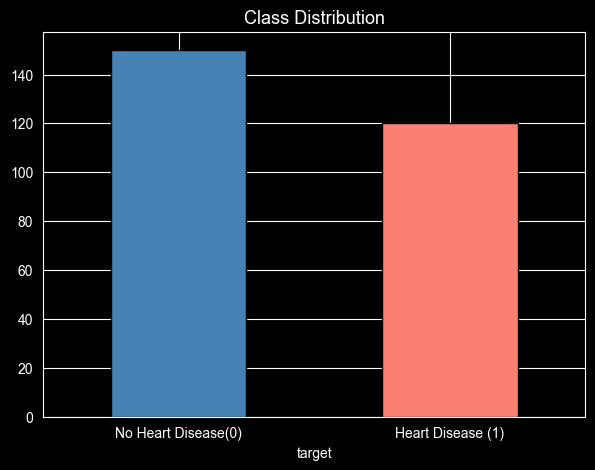

In [8]:
fig, ax = plt.subplots(figsize=(7,5))

df["target"].value_counts().plot(kind="bar",ax=ax,color=["steelblue","salmon"],edgecolor="black",width=0.5)
ax.set_title("Class Distribution",fontsize=13)
ax.set_xticklabels(["No Heart Disease(0)","Heart Disease (1)"],rotation=0)


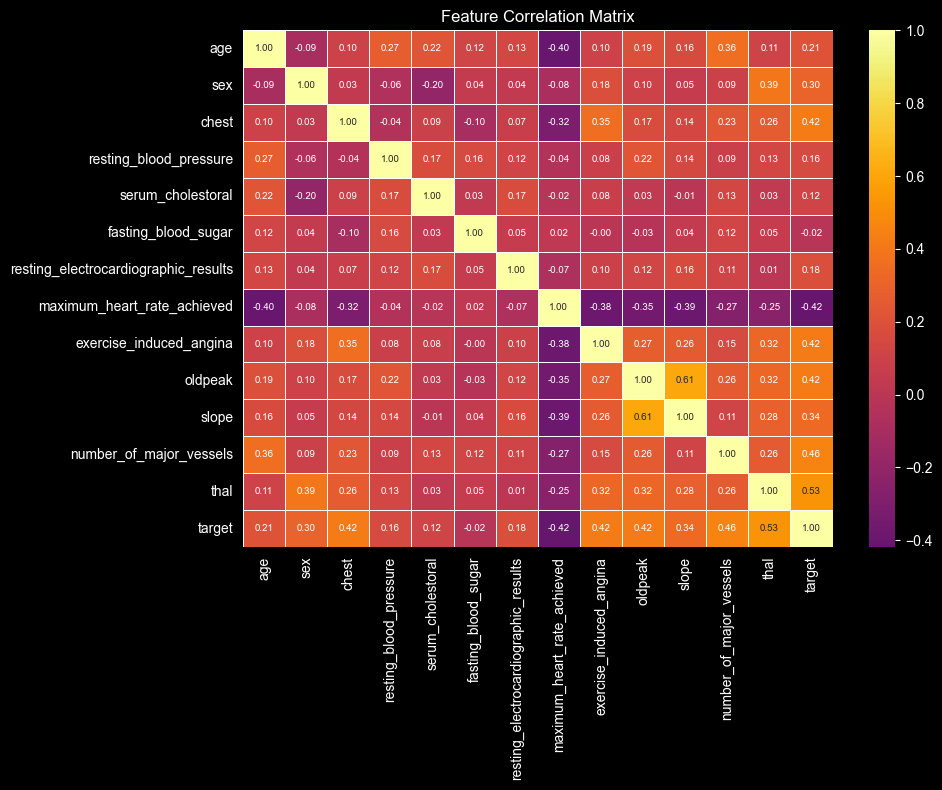

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="inferno",center=0,linewidths=0.5,ax=ax,annot_kws={"size":7})
ax.set_title("Feature Correlation Matrix",fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
X = df.drop("target",axis=1)
y = df["target"]
feature_names = X.columns.tolist()

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=42,stratify=y)

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")

X_train shape (216, 13)
X_test shape (54, 13)


In [25]:
dt_clf = DecisionTreeClassifier(max_depth=3,criterion="gini",random_state=42)

dt_clf.fit(X_train,y_train)
y_train_pred = dt_clf.predict(X_train)
y_pred = dt_clf.predict(X_test)
print(f"Train Accuracy: {accuracy_score(y_train,y_train_pred)}")
print(f"Test Accuracy: {accuracy_score(y_test,y_pred)}")

print(classification_report(y_test,y_pred,target_names=["No Heart Disease(0)","Heart Disease(1)"]))

Train Accuracy: 0.8611111111111112
Test Accuracy: 0.8333333333333334
                     precision    recall  f1-score   support

No Heart Disease(0)       0.92      0.77      0.84        30
   Heart Disease(1)       0.76      0.92      0.83        24

           accuracy                           0.83        54
          macro avg       0.84      0.84      0.83        54
       weighted avg       0.85      0.83      0.83        54



In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.76      0.92      0.83        24

    accuracy                           0.83        54
   macro avg       0.84      0.84      0.83        54
weighted avg       0.85      0.83      0.83        54



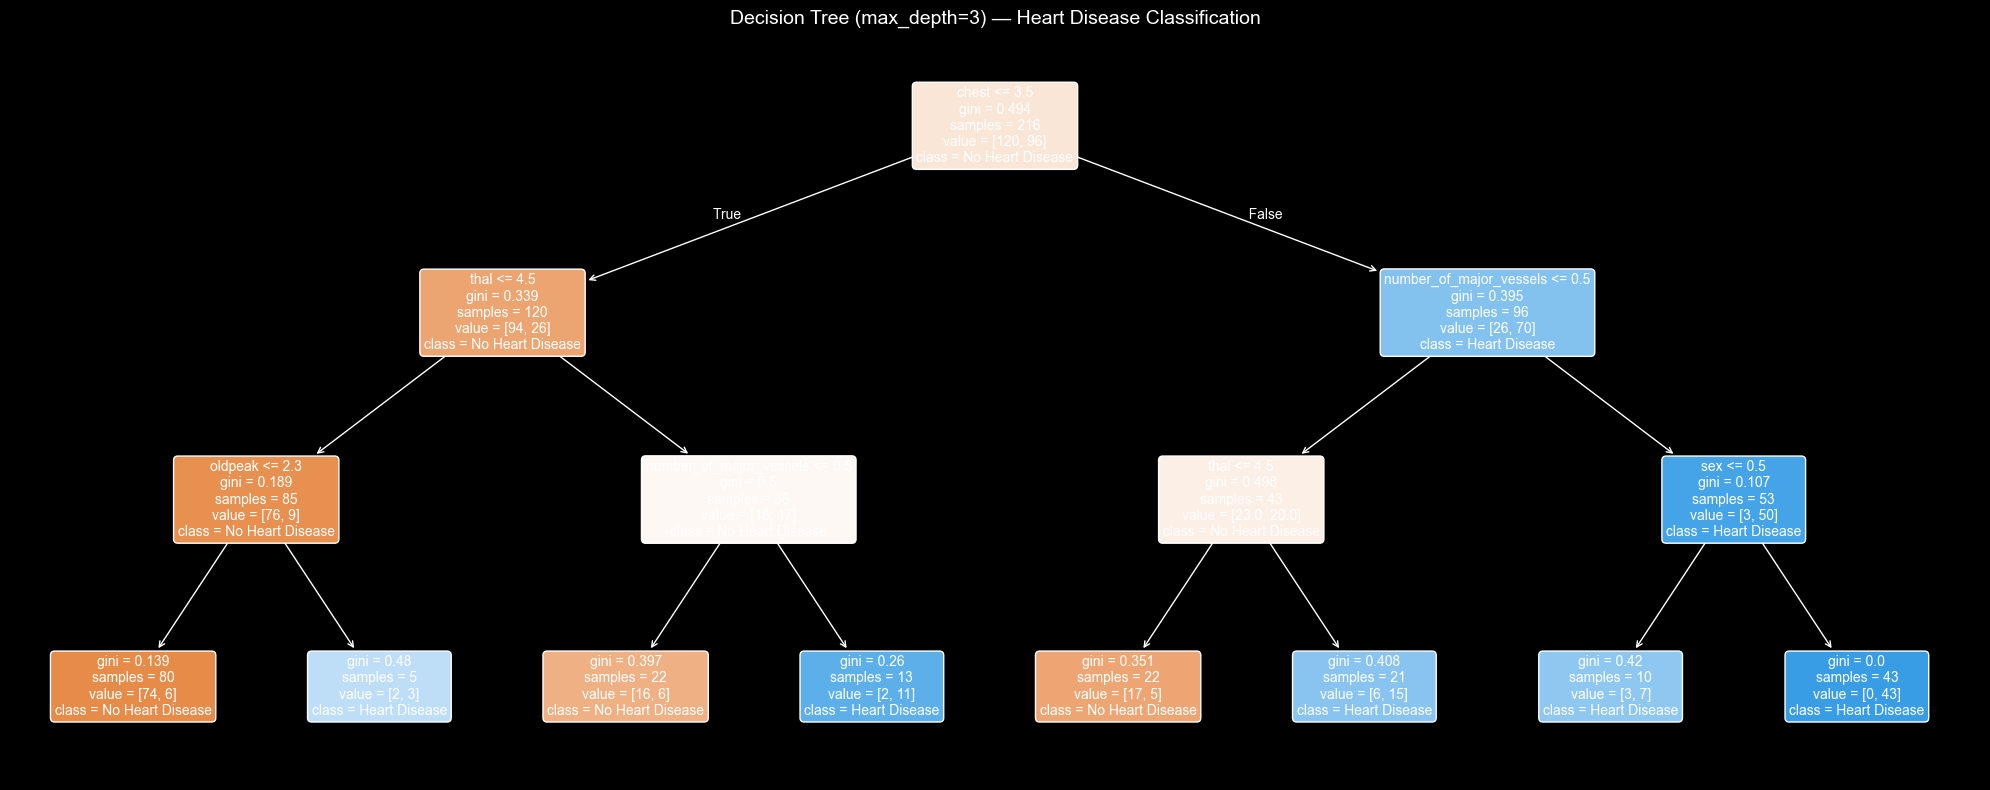

In [27]:
plt.figure(figsize=(20,8))
plot_tree(dt_clf,feature_names=feature_names,class_names=["No Heart Disease","Heart Disease"],filled=True,rounded=True,fontsize=10,impurity=True,proportion=False)
plt.title('Decision Tree (max_depth=3) — Heart Disease Classification', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
print(export_text(dt_clf,feature_names=feature_names))

|--- chest <= 3.50
|   |--- thal <= 4.50
|   |   |--- oldpeak <= 2.30
|   |   |   |--- class: 0
|   |   |--- oldpeak >  2.30
|   |   |   |--- class: 1
|   |--- thal >  4.50
|   |   |--- number_of_major_vessels <= 0.50
|   |   |   |--- class: 0
|   |   |--- number_of_major_vessels >  0.50
|   |   |   |--- class: 1
|--- chest >  3.50
|   |--- number_of_major_vessels <= 0.50
|   |   |--- thal <= 4.50
|   |   |   |--- class: 0
|   |   |--- thal >  4.50
|   |   |   |--- class: 1
|   |--- number_of_major_vessels >  0.50
|   |   |--- sex <= 0.50
|   |   |   |--- class: 1
|   |   |--- sex >  0.50
|   |   |   |--- class: 1



In [29]:
feature_names

['age',
 'sex',
 'chest',
 'resting_blood_pressure',
 'serum_cholestoral',
 'fasting_blood_sugar',
 'resting_electrocardiographic_results',
 'maximum_heart_rate_achieved',
 'exercise_induced_angina',
 'oldpeak',
 'slope',
 'number_of_major_vessels',
 'thal']

In [30]:
train_accs,test_accs = [],[]
depths = range(1,20)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d,random_state=42)
    clf.fit(X_train,y_train)
    train_accs.append(accuracy_score(y_train,clf.predict(X_train)))
    test_accs.append((accuracy_score(y_test,clf.predict(X_test))))

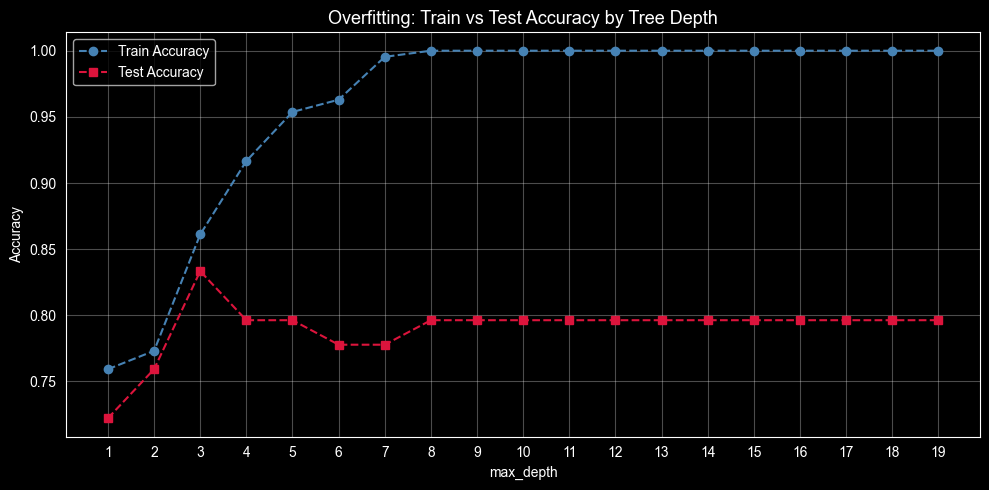

Best test accuracy at max_depth=3: 0.8333
Notice: train accuracy reaches 1.0 long before test accuracy peaks — that's overfitting.


In [32]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy',
         color='steelblue', linestyle='--', markerfacecolor='steelblue')
plt.plot(depths, test_accs, marker='s', label='Test Accuracy',
         color='crimson', linestyle='--', markerfacecolor='crimson')
plt.title('Overfitting: Train vs Test Accuracy by Tree Depth', fontsize=13)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(list(depths))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths.start + np.argmax(test_accs)
print(f"Best test accuracy at max_depth={best_depth}: {max(test_accs):.4f}")
print("Notice: train accuracy reaches 1.0 long before test accuracy peaks — that's overfitting.")

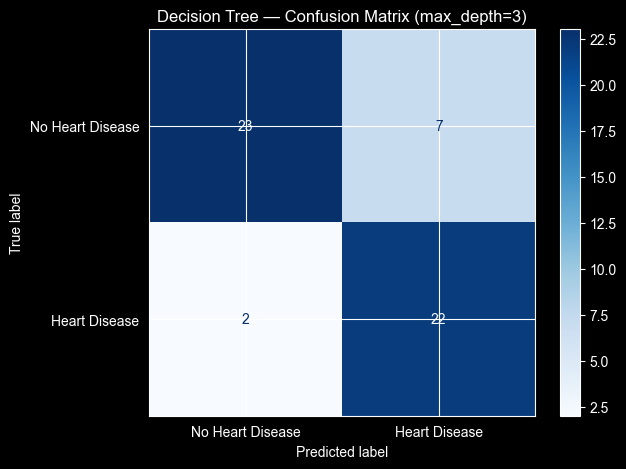

In [35]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Heart Disease","Heart Disease"])
disp.plot(cmap="Blues")
plt.title('Decision Tree — Confusion Matrix (max_depth=3)')
plt.tight_layout()
plt.show()

In [36]:
try:
    df_ins = pd.read_csv('data/insurance.csv')
    print("Loaded from CSV.")
except FileNotFoundError:
    from sklearn.datasets import make_regression
    rng = np.random.default_rng(42)
    n = 1338
    age = rng.integers(18, 65, n)
    bmi = rng.normal(30, 6, n).clip(15, 55)
    children = rng.integers(0, 5, n)
    smoker = rng.integers(0, 2, n)
    charges = (age * 250 + bmi * 330 + children * 400
               + smoker * 24000 + rng.normal(0, 2500, n)).clip(1000)
    df_ins = pd.DataFrame({'age': age, 'bmi': bmi, 'children': children,
                            'smoker': smoker, 'charges': charges})
    print("CSV not found — using synthetic data.")

# Encode categorical columns if present
if df_ins['smoker'].dtype == object:
    df_ins['smoker'] = df_ins['smoker'].map({'yes': 1, 'no': 0})
if 'sex' in df_ins.columns and df_ins['sex'].dtype == object:
    df_ins['sex'] = df_ins['sex'].map({'male': 0, 'female': 1})
if 'region' in df_ins.columns and df_ins['region'].dtype == object:
    df_ins = pd.get_dummies(df_ins, columns=['region'], drop_first=True)

print(f"Dataset shape: {df_ins.shape}")
df_ins.head()

CSV not found — using synthetic data.
Dataset shape: (1338, 5)


,age,bmi,children,smoker,charges
0,22,27.976049,0,1,37716.762065
1,54,29.147981,1,1,44947.573033
2,48,33.691541,4,1,48175.349366
3,38,19.615970,2,0,17466.630670
4,38,30.986344,1,1,42888.622516


In [38]:
X_reg = df_ins.drop("charges",axis=1)
y_reg = df_ins["charges"]
reg_feature_names= X_reg.columns.tolist()

In [39]:
reg_feature_names

['age', 'bmi', 'children', 'smoker']

In [40]:
X_train_r,X_test_r,y_train_r,y_test_r = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)
dt_reg = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_reg.fit(X_train_r,y_train_r)
y_pred_dt_r = dt_reg.predict(X_test_r)


In [41]:
mae_dt  = mean_absolute_error(y_test_r, y_pred_dt_r)
rmse_dt = np.sqrt(mean_squared_error(y_test_r, y_pred_dt_r))
r2_dt   = r2_score(y_test_r, y_pred_dt_r)

In [42]:
print("--- Decision Tree Regression (max_depth=4) ---")
print(f"MAE  : ${mae_dt:,.0f}")
print(f"RMSE : ${rmse_dt:,.0f}")
print(f"R²   : {r2_dt:.4f}")

--- Decision Tree Regression (max_depth=4) ---
MAE  : $2,211
RMSE : $2,807
R²   : 0.9507


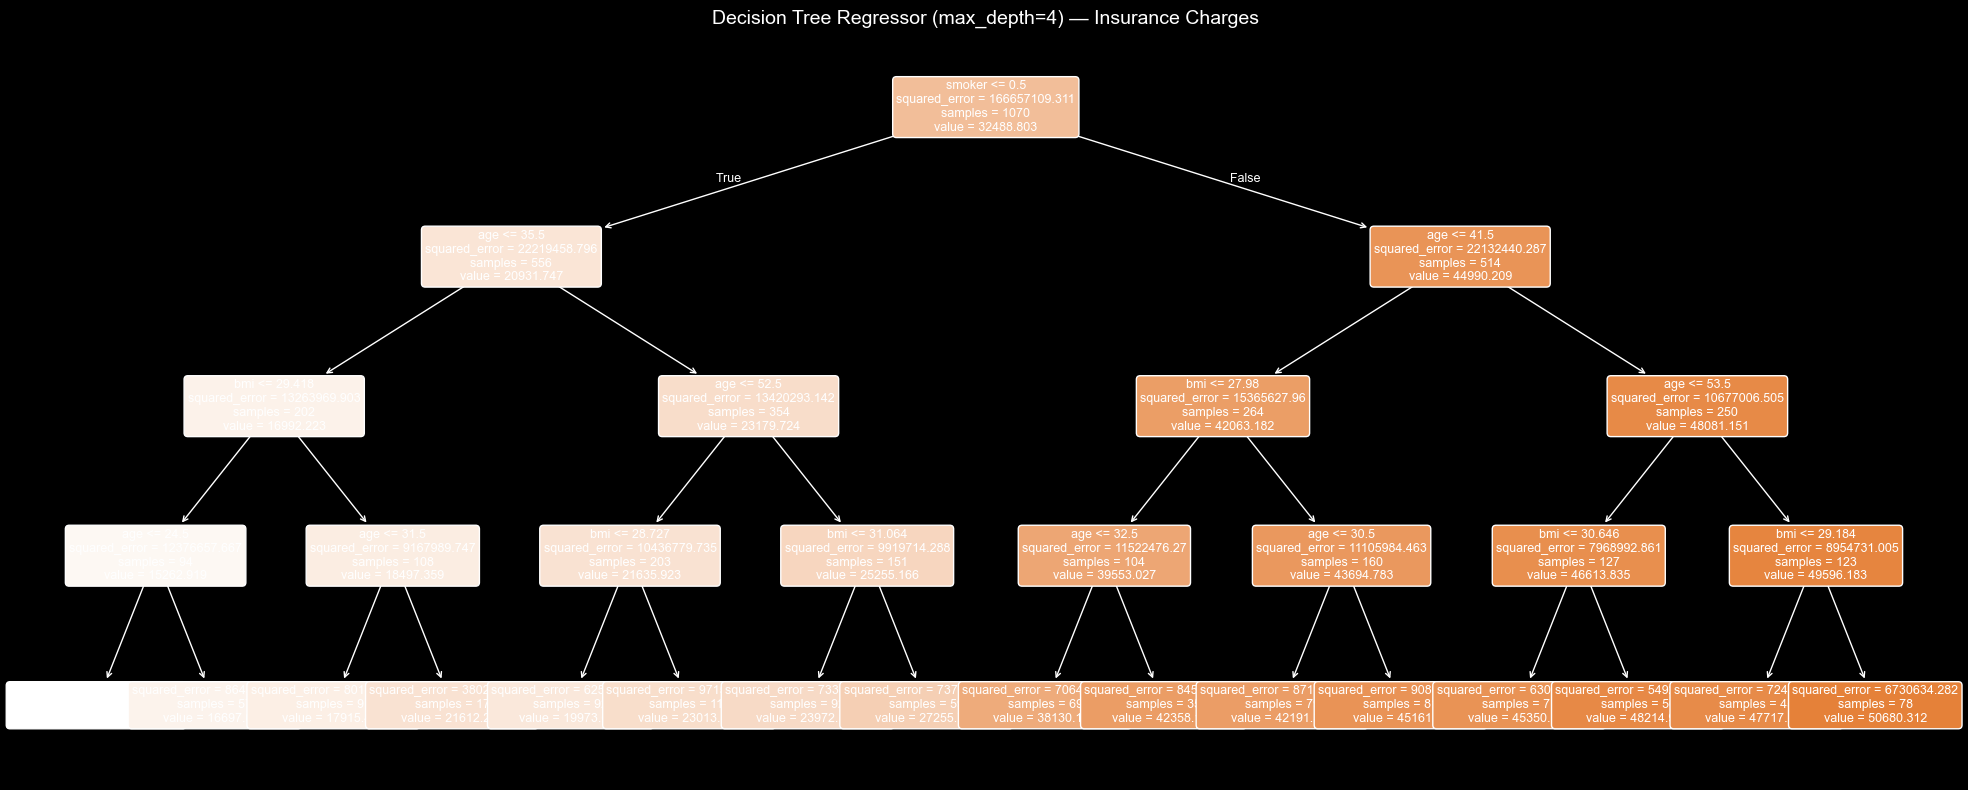

In [43]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_reg,
    feature_names=reg_feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True
)
plt.title('Decision Tree Regressor (max_depth=4) — Insurance Charges', fontsize=14)
plt.tight_layout()
plt.show()